# Seeding script

In [ ]:
import xarray as xr
# import iris
import xnemogcm
import numpy as np
import matplotlib.pyplot as plt
import dask.array as da
import dask.dataframe as dd
import os
import cmocean
from matplotlib.collections import PolyCollection
import matplotlib
import pandas as pd

benchmark=False  #Set to true if you want to create just one seeding file for benchmarking purposes
subsample = True # = True create a subsampling file for TRACMASS to use (seedtype = 3 in TRACMASS, subsamplefile in TRACMASS namelist)
nsdtim = 1       # Number of seeding occurences in TRACMASS experiment
nsdPerCellAvg = 15 # Average number of trajectories per grid cell (only used to estimate length of file, must match nsdPerCellAvg in TRACMASS namelist)

First locate the domain files for the configuration

In [38]:
data_dir = os.path.abspath("/gws/nopw/j04/bas_pog/astyles/DRAKKAR_SET/topo/") #For ORCA025
out_dir = os.path.abspath("/gws/nopw/j04/bas_pog/astyles/DRAKKAR_SET/seeding/seeding_subsampled_30x398/") # For ORCA025
if not os.path.exists(out_dir): os.mkdir(out_dir)


In [39]:
ds_nemo = xnemogcm.open_domain_cfg(data_dir, ['mesh_hgr.nc', 'mesh_zgr.nc', 'mask.nc'])
bathy_level = ds_nemo['mbathy']
bathy_array = bathy_level.astype(int).values
tmask = ds_nemo['tmask'].astype(bool).values

# Horizontal Chunking

In [42]:
chunki = 30     #None for no chunking in i-direction
chunkj = 398  #None for no chunking in j-direction

# #ORCA025
ist1 = 1    #As defined in TRACMASS namelist
ist2 = 1440 #As defined in TRACMASS namelist
jst1 = 1    #As defined in TRACMASS namelist 
jst2 = 398  #As defined in TRACMASS namelist

# ORCA12
# ist1 = 1      #As defined in TRACMASS namelist
# ist2 = 4320   #As defined in TRACMASS namelist
# jst1 = 1      #As defined in TRACMASS namelist 
# jst2 = 1198   #As defined in TRACMASS namelist

# #CUSTOM
# ist1 = 3200  #As defined in TRACMASS namelist
# ist2 = 3200 #As defined in TRACMASS namelist
# jst1 = 1   #As defined in TRACMASS namelist 
# jst2 = 900   #As defined in TRACMASS namelist

In [43]:
if chunki is not None:
    ni_chunk = int(np.ceil((ist2-ist1+1)/chunki))
    istmin = ist1 + chunki*np.linspace(0,ni_chunk-1,num=ni_chunk, dtype=int)
    istmax = istmin + chunki-1
    if istmax[-1] > ist2: istmax[-1] = ist2
else:
    istmin = [ist1]
    istmax = [ist2]
    
if chunkj is not None:   
    nj_chunk = int(np.ceil((jst2-jst1+1)/chunkj))
    jstmin = jst1 + chunkj*np.linspace(0,nj_chunk-1,num=nj_chunk, dtype=int)
    jstmax = jstmin + chunkj-1
    if jstmax[-1] > jst2: jstmax[-1] = jst2
else:
    jstmin = [jst1]
    jstmax = [jst2]
    
nsubdomain_i = len(istmin)
nsubdomain_j = len(jstmin)
nsubdomain = nsubdomain_i * nsubdomain_j

subdomain = []
for i in range(nsubdomain_i):
    for j in range(nsubdomain_j):
        subdomain = subdomain + [(istmin[i], istmax[i], jstmin[j], jstmax[j])]

In [44]:
subdomain

[(1, 30, 1, 398),
 (31, 60, 1, 398),
 (61, 90, 1, 398),
 (91, 120, 1, 398),
 (121, 150, 1, 398),
 (151, 180, 1, 398),
 (181, 210, 1, 398),
 (211, 240, 1, 398),
 (241, 270, 1, 398),
 (271, 300, 1, 398),
 (301, 330, 1, 398),
 (331, 360, 1, 398),
 (361, 390, 1, 398),
 (391, 420, 1, 398),
 (421, 450, 1, 398),
 (451, 480, 1, 398),
 (481, 510, 1, 398),
 (511, 540, 1, 398),
 (541, 570, 1, 398),
 (571, 600, 1, 398),
 (601, 630, 1, 398),
 (631, 660, 1, 398),
 (661, 690, 1, 398),
 (691, 720, 1, 398),
 (721, 750, 1, 398),
 (751, 780, 1, 398),
 (781, 810, 1, 398),
 (811, 840, 1, 398),
 (841, 870, 1, 398),
 (871, 900, 1, 398),
 (901, 930, 1, 398),
 (931, 960, 1, 398),
 (961, 990, 1, 398),
 (991, 1020, 1, 398),
 (1021, 1050, 1, 398),
 (1051, 1080, 1, 398),
 (1081, 1110, 1, 398),
 (1111, 1140, 1, 398),
 (1141, 1170, 1, 398),
 (1171, 1200, 1, 398),
 (1201, 1230, 1, 398),
 (1231, 1260, 1, 398),
 (1261, 1290, 1, 398),
 (1291, 1320, 1, 398),
 (1321, 1350, 1, 398),
 (1351, 1380, 1, 398),
 (1381, 1410, 1, 

There is no point seeding land only areas. Test if areas are land only

In [45]:
subdomain_land = []

for sdom in subdomain:
    imin, imax, jmin, jmax = sdom
    array = bathy_array[jmin:jmax+1, imin:imax+1]
    array_max = array.max()
    if array_max > 0:
        subdomain_land = subdomain_land + [sdom]

nsubdomain_land = len(subdomain_land)

# Plot chunks

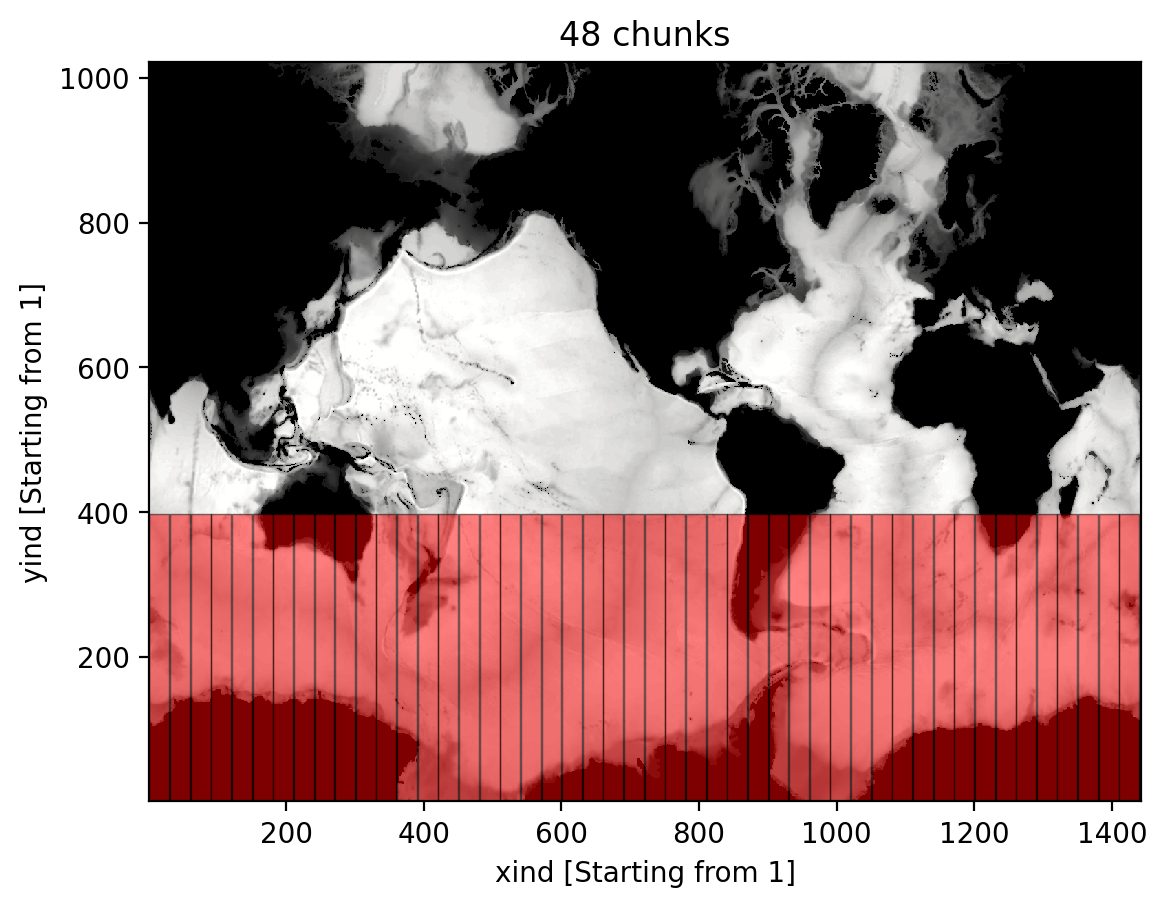

In [46]:
fig, ax = plt.subplots(dpi=200)
ax.pcolormesh(np.array(range(bathy_array.shape[-1]))+1, np.array(range(bathy_array.shape[-2]))+1, bathy_array, cmap=cmocean.cm.gray)

coll = PolyCollection( [[  [s[0],s[2]],
                           [s[0],s[3]],
                           [s[1],s[3]],
                           [s[1],s[2]]] for s in subdomain_land], facecolor='red', edgecolor='k', linewidth=0.5, alpha=0.5)
ax.add_collection(coll)
ax.set_title(fr"{nsubdomain_land} chunks")
ax.set_xlabel(r"xind [Starting from 1]")
ax.set_ylabel(r"yind [Starting from 1]")
plt.show()

# Create seeding files

Our seeding files need the following information in the following order to be understood by TRACMASS:

* `i`: i-coordinate of seeding T-Cell
* `j`: j-coordinate of seeding T-Cell
* `k`: k-coordinate of seeding T-Cell
* `isec` : Cell wall to be considered (1) Zonal, U  (2) Meridional, V (3) Vertical, W
* `idir` : Positive or negative volume fluxes (+1) Positive  (-1) Negative

We create a seeding file for each chunk shown above

In [47]:
kmin = 1
kmax = 75
kcoord = np.linspace(1,75, num=75, dtype=int)
npoints_k = int(kmax-kmin+1)
isec = 1

for sdom in subdomain_land:
    imin, imax, jmin, jmax = sdom
    filename = f"seed_chunk_imin{imin:04d}_imax{imax:04d}_jmin{jmin:04d}_jmax{jmax:04d}.csv"
    
    npoints = int((imax-imin+1)*(jmax-jmin+1))
    npoints_i = int(imax-imin+1)
    npoints_j = int(jmax-jmin+1)
    
    
    icoord = np.linspace(imin, imax, num=npoints_i, dtype=int)
    jcoord = np.linspace(jmin, jmax, num=npoints_j, dtype=int)
    dircoord = np.array([-1,+1], dtype=int)
    
    
    
    kgrid, dirgrid, jgrid, igrid, = np.meshgrid(kcoord,dircoord, jcoord, icoord)
    tmask_grid = tmask[np.newaxis, kmin-1:kmax, jmin-1:jmax, imin-1:imax]



    tmask_grid = np.broadcast_to(tmask_grid, jgrid.shape)
    
    i_points = igrid.flatten()[tmask_grid.flatten()]
    j_points = jgrid.flatten()[tmask_grid.flatten()]
    k_points = kgrid.flatten()[tmask_grid.flatten()]
    isec_points = np.broadcast_to(isec, kgrid.flatten().shape)[tmask_grid.flatten()]
    idir_points = dirgrid.flatten()[tmask_grid.flatten()]
    
    if subsample == True:
        random_numbers = np.random.random_sample(len(i_points) * nsdtim * nsdPerCellAvg)
        seed_randomnumbers = {"randomnumber":random_numbers}
        pd.DataFrame.from_dict(seed_randomnumbers).to_csv(out_dir + "/random." + filename, header=None, index=None, lineterminator=",\n")


#     seed = {"i": igrid.flatten()[tmask_grid.flatten()], "j":jgrid.flatten()[tmask_grid.flatten()],
#             "k":kgrid.flatten()[tmask_grid.flatten()], "isec": np.broadcast_to(isec, kgrid.flatten().shape)[tmask_grid.flatten()],
#             "idir": dirgrid.flatten()[tmask_grid.flatten()]}
    
    seed = {"i": i_points, "j": j_points,
            "k": k_points, "isec": isec_points,
            "idir": idir_points}
    

    
    
    pd.DataFrame.from_dict(seed).to_csv(out_dir + "/" + filename, header=None, index=None, lineterminator=",\n")
    
    if benchmark == True: break